# Email Text Generation for Autocomplete Using Transformer Models

This notebook runs steps for baseline N-gram models as well as fine-tuning a Transformer model (`distilgpt2`)

Flow of this notebook consists of following:
1. Environment Set-up
2. Evaluation (compares models in `src/test_evaluation.py`)
3. Prepare data for fine-tuning
4. Create subset data files (as use of all the original data resulted in long execution)
5. Rune fine-tuning using data from Step 4
6. Evaluation of fine-tuned model


## 1. Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2 Install Required Libraries and set up environments
- the first cell is the priginal installation
- the second two are to avoid getting errors/ warning, and termination.

In [2]:
!pip install pandas scikit-learn nltk transformers torch tqdm huggingface_hub accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 101.4 MB/s eta 0:00:00


In [4]:
import transformers
print(transformers.__version__)

4.51.1


In [5]:
# Install the specific pandas version needed and update others as I kept getting this error.
!pip install pandas==2.2.2 -q
!pip install --upgrade transformers accelerate torch scikit-learn nltk tqdm huggingface_hub -q

print("Libraries check/upgrade complete (pandas pinned to 2.2.2).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 30.8 MB/s eta 0:00:00
Libraries check/upgrade complete (pandas pinned to 2.2.2).


Download NLTK Data

In [5]:
import nltk

resources_to_download = ['punkt', 'punkt_tab']

print("Checking required NLTK resources...")
all_downloaded = True
for resource in resources_to_download:
    try:
        if resource == 'punkt_tab':
             nltk.data.find(f'tokenizers/punkt_tab/english/')
        else:
             nltk.data.find(f'tokenizers/{resource}')
        print(f"- NLTK '{resource}' resource found.")
    except LookupError:
        all_downloaded = False
        print(f"- NLTK '{resource}' resource NOT FOUND. Attempting download...")
        try:

            nltk.download(resource, quiet=True)
            if resource == 'punkt_tab':
                 nltk.data.find(f'tokenizers/punkt_tab/english/')
            else:
                 nltk.data.find(f'tokenizers/{resource}')
            print(f"  '{resource}' download complete.")
        except Exception as e:
            print(f"!!! Download FAILED for '{resource}'. Error: {e}. Tokenization might fail. !!!")
            all_downloaded = False

if all_downloaded:
    print("All required NLTK resources seem available.")
else:
    print("Warning: Some NLTK resources could not be downloaded.")

Checking required NLTK resources...
- NLTK 'punkt' resource NOT FOUND. Attempting download...
  'punkt' download complete.
- NLTK 'punkt_tab' resource NOT FOUND. Attempting download...
  'punkt_tab' download complete.


## 3 Change Directory to Designated Project Folder on Google Drive

In [6]:
# IMPORTANT: check the location of 'project' folder on Google Drive/ Github
%cd /content/drive/MyDrive/project

/content/drive/MyDrive/project


Below is to avoid the "leaked semaphore" warning I had on my PC, just to be causious.

In [7]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## 4. Run Model Evaluation Script

This cell executes the main evaluation pipeline defined in `src/test_evaluation.py`.

** NOTE**
* Decide which Transformer model to evaluate *in this run*.
* Edit `src/test_evaluation.py` and set the `TRANSFORMER_MODEL_ID` variable accordingly (`"distilgpt2"` for the pre-trained version, or to `"/content/drive/MyDrive/project/fine_tuned_distilgpt2_subset_test"` for fine-tuned version). Before run, make sure it was saved!

In [9]:
!python -m src.test_evaluation

2025-04-18 07:24:46.538022: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744961086.559903   22899 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744961086.566366   22899 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-18 07:24:46.587887: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
--- Starting Evaluation Pipeline ---

[1. Loading and Preprocessing Data]
Successfully loaded 517401 rows from /content/drive

## ** Inspect Detailed Evaluation Results **

To analyze why pre-trained distilgpt2 got zeros, load evaluation_results_detailed.csv file and print ros `prompt`, `ground_truth`, and `transformer_suggestion`.

In [ ]:
import pandas as pd

results_csv_path = '/content/drive/MyDrive/project/evaluation_results_detailed.csv'

try:
    df_results = pd.read_csv(results_csv_path)

    print("Displaying first 5 rows of the detailed results:")
    from IPython.display import display
    display(df_results.head())

    print("\nShowing Prompt, Ground Truth, and Transformer Suggestion for first 5 rows:")
    display(df_results[['prompt', 'ground_truth', 'transformer_suggestion']].head())

except FileNotFoundError:
    print(f"Error: Results file not found at {results_csv_path}")
    print("Please ensure test_evaluation.py ran successfully and saved the file.")
except Exception as e:
    print(f"An error occurred loading the CSV: {e}")

Displaying first 5 rows of the detailed results:


,prompt,ground_truth,transformer_suggestion,transformer_time,transformer_word_acc,transformer_char_acc,transformer_ksr,word_ngram_suggestion,word_ngram_time,word_ngram_word_acc,word_ngram_char_acc,word_ngram_ksr,char_ngram_suggestion,char_ngram_time,char_ngram_word_acc,char_ngram_char_acc,char_ngram_ksr
0,message-id: <20517293.1075855790679.javamail.e...,"sally.beck@enron.com, brent.price@enron.com mi...",james.watson@nj.edu Subject: core operating st...,1.360584,0,0,0.0,paul.pizzolato rob.walls chonawee.supatgiat je...,0.501734,0,0,0.00000,...,0.007526,0.0,0,0.0
1,message-id: <13986599.1075857677352.javamail.e...,"7bit x-from: kishkill, joe x-to: lavorato, joh...",no-text; text-size: 0; font-family: sans-serif...,1.212199,0,0,0.0,7bit,0.000446,1,1,0.00278,...,0.005528,0.0,0,0.0
2,message-id: <5560482.1075857480882.javamail.ev...,x-from: jane m tholt x-to: laurie ellis x-cc: ...,"charsets=utf-8, text-size: 2.5, font-family: s...",1.209608,0,0,0.0,bcc,0.000553,0,0,0.00000,"hmhy ieh loy yeiihthyh'yht= ,s.t eh hie s ahht...",0.015665,0.0,0,0.0
3,message-id: <2532318.1075845800919.javamail.ev...,"john.r.ayres@enron.com, toxley@winston.com, be...","kennie.simmons@seattle.edu, jennies.michael.ke...",1.266740,0,0,0.0,barbara.hueter steven.kean robert.johnston nel...,0.478489,0,0,0.00000,...,0.010377,0.0,0,0.0
4,message-id: <9119525.1075843959287.javamail.ev...,mime-version: 1.0 content-type: text/plain; ch...,The following is a list of the most recent oil...,1.285608,0,0,0.0,advance you i please to,0.001940,0,0,0.00000,c c cg c bi csn nc bfec db...,0.014655,0.0,0,0.0



Showing Prompt, Ground Truth, and Transformer Suggestion for first 5 rows:


,prompt,ground_truth,transformer_suggestion
0,message-id: <20517293.1075855790679.javamail.e...,"sally.beck@enron.com, brent.price@enron.com mi...",james.watson@nj.edu Subject: core operating st...
1,message-id: <13986599.1075857677352.javamail.e...,"7bit x-from: kishkill, joe x-to: lavorato, joh...",no-text; text-size: 0; font-family: sans-serif...
2,message-id: <5560482.1075857480882.javamail.ev...,x-from: jane m tholt x-to: laurie ellis x-cc: ...,"charsets=utf-8, text-size: 2.5, font-family: s..."
3,message-id: <2532318.1075845800919.javamail.ev...,"john.r.ayres@enron.com, toxley@winston.com, be...","kennie.simmons@seattle.edu, jennies.michael.ke..."
4,message-id: <9119525.1075843959287.javamail.ev...,mime-version: 1.0 content-type: text/plain; ch...,The following is a list of the most recent oil...


## 4. Prepare Full Dataset Text Files for Fine-Tuning

This cell prepares the input data required by the Hugging Face `Trainer` for fine-tuning the Transformer model on the training and validation sets.

In [ ]:
import pandas as pd
import os

from src.data_preprocessing import load_full_dataset, preprocess_data, split_data

print("--- Preparing Data for Fine-Tuning ---")

DATA_FILE_PATH = "/content/drive/MyDrive/project/emails.csv"

train_file_path = 'train.txt'
val_file_path = 'val.txt'

print("\n[1. Loading and Preprocessing Data]")
full_df = load_full_dataset(DATA_FILE_PATH)

if full_df is None or full_df.empty:
    print("Failed to load data. Cannot proceed.")
else:
    processed_df = preprocess_data(full_df, text_col='message')
    if processed_df.empty:
        print("Preprocessing resulted in empty dataframe. Cannot proceed.")
    else:

        print("\n[2. Splitting Data]")

        train_df, val_df, test_df = split_data(processed_df, test_size=0.15, validation_size=0.15, random_state=42)

        if train_df.empty or val_df.empty:
             print("Train or Validation DataFrame is empty after split. Cannot proceed.")
        else:

             print("\n[3. Saving Text Files]")
             try:
                print(f"Saving training data ({len(train_df)} rows) to {train_file_path}...")
                train_df['clean_text'].to_csv(train_file_path, index=False, header=False)

                print(f"Saving validation data ({len(val_df)} rows) to {val_file_path}...")
                val_df['clean_text'].to_csv(val_file_path, index=False, header=False)

                print("\nData files saved successfully.")
                print(f"Please verify '{train_file_path}' and '{val_file_path}' exist in /content/drive/MyDrive/project/")

             except KeyError:
                print("\nError: 'clean_text' column not found in DataFrame. Ensure preprocessing ran correctly.")
             except Exception as e:
                print(f"\nAn error occurred saving the text files: {e}")

print("\n--- Data Preparation Cell Complete ---")

--- Preparing Data for Fine-Tuning ---

[1. Loading and Preprocessing Data]
Successfully loaded 517401 rows from /content/drive/MyDrive/project/emails.csv
Dataset size after dropping NA in 'message': 517401 rows
Dataset size after cleaning and removing empty texts: 517401 rows

[2. Splitting Data]
Data split: Train=362180, Validation=77610, Test=77611

[3. Saving Text Files]
Saving training data (362180 rows) to train.txt...
Saving validation data (77610 rows) to val.txt...

Data files saved successfully.
Please verify 'train.txt' and 'val.txt' exist in /content/drive/MyDrive/project/

--- Data Preparation Cell Complete ---


## 5. Create Subset Data Files for Faster Fine-Tuning Test

This cell creates smaller subset files (`train_subset.txt`, `val_subset.txt`) containing only the first N lines from the full text files generated above.


Note using full dataset from step 4 led to shutting down due to RAM limit, trying with smaller dataset

In [ ]:
!head -n 10000 train.txt > train_subset.txt
!head -n 2000 val.txt > val_subset.txt
print("Created subset files: train_subset.txt (10k lines), val_subset.txt (2k lines)")

Created subset files: train_subset.txt (10k lines), val_subset.txt (2k lines)


## 6. Run Fine-Tuning Process

This cell executes the fine-tuning procedure defined in `src/model.py` using the `fine_tune_transformer` function.


In [ ]:
from src.model import fine_tune_transformer
import os
import time


output_dir = "/content/drive/MyDrive/project/fine_tuned_distilgpt2_subset_test"

train_data_file = "train_subset.txt" # <-- Used subset data to avoid crashing
val_data_file = "val_subset.txt"   # <-- Used subset data to avoid crashing

print("-" * 30)
print(f"Starting fine-tuning process on SUBSET...")
print(f"Base Model: distilgpt2")
print(f"Training Data: {train_data_file}")
print(f"Validation Data: {val_data_file}")
print(f"Output Directory: {output_dir}")
print("-" * 30)

start_tune_time = time.time()

# Using 1 epoch and batch size 8 as starting points for T4 GPU
fine_tuned_model_path = fine_tune_transformer(
    base_model_name="distilgpt2",
    train_file_path=train_data_file,
    eval_file_path=val_data_file,
    output_dir=output_dir,
    epochs=1,
    batch_size=4 #changed from 8 as the execution stopped everytime. A smaller batch size uses less memory per step.
)

end_tune_time = time.time()
print("-" * 30)

if fine_tuned_model_path:
    print(f"Fine-tuning process finished in {(end_tune_time - start_tune_time)/60:.2f} minutes.")
    print(f"Fine-tuned model should be saved in: {fine_tuned_model_path}")
    %env FINE_TUNED_MODEL_PATH={fine_tuned_model_path}
else:
    print("Fine-tuning process failed or was interrupted.")
    %env FINE_TUNED_MODEL_PATH=""

------------------------------
Starting fine-tuning process on SUBSET...
Base Model: distilgpt2
Training Data: train_subset.txt
Validation Data: val_subset.txt
Output Directory: /content/drive/MyDrive/project/fine_tuned_distilgpt2_subset_test
------------------------------
--- Starting Transformer Fine-Tuning (Placeholder) ---
Loading transformer model: distilgpt2
Using device: GPU


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...

/usr/local/lib/python3.11/dist-packages/transformers/data/datasets/language_modeling.py:53: FutureWarning: This dataset will be removed from the library soon, preprocessing should be handled with the 🤗 Datasets library. You can have a look at this example script for pointers: https://github.com/huggingface/transformers/blob/main/examples/pytorch/language-modeling/run_mlm.py
  warnings.warn(


Setting up Training Arguments...
Starting fine-tuning training...


`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
100,4.344200
200,3.766700
300,3.416500
400,3.454000
500,3.323300
600,3.286000
700,3.278200
800,3.195500
900,3.113800
1000,3.214300


Fine-tuning completed.
Saving fine-tuned model to /content/drive/MyDrive/project/fine_tuned_distilgpt2_subset_test
Model and tokenizer saved.
------------------------------
Fine-tuning process finished in 70.32 minutes.
Fine-tuned model should be saved in: /content/drive/MyDrive/project/fine_tuned_distilgpt2_subset_test
env: FINE_TUNED_MODEL_PATH=/content/drive/MyDrive/project/fine_tuned_distilgpt2_subset_test


## Additional Note:
- drawing loss curve graph for presentation slide

Plotting 223 step points vs 223 loss points.


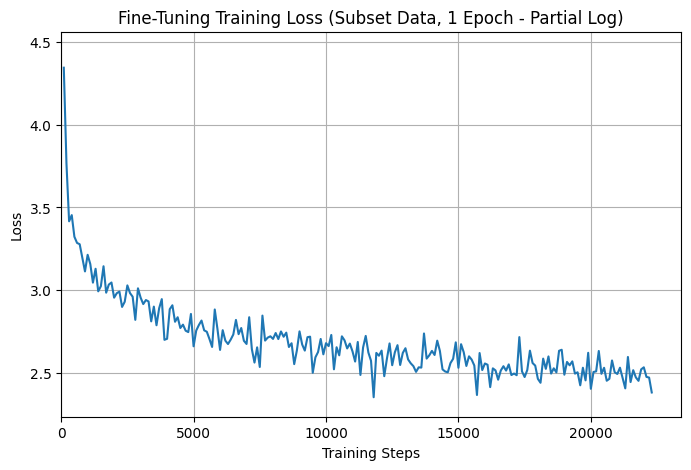

In [ ]:
import matplotlib.pyplot as plt

steps = [
    100, 200, 300, 400, 500, 600, 700, 800, 900, 1000,
    1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000,
    2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000,
    3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000,
    4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000,
    5100, 5200, 5300, 5400, 5500, 5600, 5700, 5800, 5900, 6000,
    6100, 6200, 6300, 6400, 6500, 6600, 6700, 6800, 6900, 7000,
    7100, 7200, 7300, 7400, 7500, 7600, 7700, 7800, 7900, 8000,
    8100, 8200, 8300, 8400, 8500, 8600, 8700, 8800, 8900, 9000,
    9100, 9200, 9300, 9400, 9500, 9600, 9700, 9800, 9900, 10000,
    10100, 10200, 10300, 10400, 10500, 10600, 10700, 10800, 10900, 11000,
    11100, 11200, 11300, 11400, 11500, 11600, 11700, 11800, 11900, 12000,
    12100, 12200, 12300, 12400, 12500, 12600, 12700, 12800, 12900, 13000,
    13100, 13200, 13300, 13400, 13500, 13600, 13700, 13800, 13900, 14000,
    14100, 14200, 14300, 14400, 14500, 14600, 14700, 14800, 14900, 15000,
    15100, 15200, 15300, 15400, 15500, 15600, 15700, 15800, 15900, 16000,
    16100, 16200, 16300, 16400, 16500, 16600, 16700, 16800, 16900, 17000,
    17100, 17200, 17300, 17400, 17500, 17600, 17700, 17800, 17900, 18000,
    18100, 18200, 18300, 18400, 18500, 18600, 18700, 18800, 18900, 19000,
    19100, 19200, 19300, 19400, 19500, 19600, 19700, 19800, 19900, 20000,
    20100, 20200, 20300, 20400, 20500, 20600, 20700, 20800, 20900, 21000,
    21100, 21200, 21300, 21400, 21500, 21600, 21700, 21800, 21900, 22000,
    22100, 22200, 22300, 22400, 22500, 22600, 22700, 22800, 22900, 23000,
    23100, 23200, 23300, 23400, 23500, 23600, 23700, 23800, 23900, 24000,
    24100, 24200, 24300, 24400, 24500, 24600, 24700, 24800, 24900, 25000,
    25100, 25200, 25300, 25400, 25500, 25600, 25700, 25800, 25900, 26000,
    26100, 26200, 26300, 26400, 26500, 26600, 26700, 26800, 26900, 27000,
    27100, 27200, 27300, 27400, 27500, 27600, 27700, 27800, 27900, 28000,
    28100, 28200, 28300, 28400, 28500, 28600, 28700, 28800, 28900, 29000,
    29100, 29200, 29300, 29400, 29500, 29600, 29700, 29800, 29900, 30000,
    30100, 30200, 30300, 30400, 30500, 30600, 30700, 30800, 30900, 31000,
    31100, 31200, 31300, 31400, 31500, 31600, 31700, 31800, 31900, 32000,
    32100, 32200, 32300, 32400, 32500, 32600, 32700, 32800, 32900, 33000,
    33100, 33200, 33300, 33400, 33500, 33600, 33700, 33800
]

loss = [
    4.344200, 3.766700, 3.416500, 3.454000, 3.323300, 3.286000, 3.278200, 3.195500, 3.113800, 3.214300,
    3.158700, 3.046300, 3.129900, 2.993600, 3.024800, 3.145100, 2.985500, 3.034500, 3.047000, 2.955400,
    2.982400, 2.992200, 2.899500, 2.930600, 3.029600, 2.983100, 2.961200, 2.821500, 3.012000, 2.955900,
    2.916800, 2.941100, 2.932500, 2.812400, 2.901400, 2.788800, 2.891300, 2.946800, 2.700900, 2.707100,
    2.885700, 2.909500, 2.809900, 2.837200, 2.772200, 2.792500, 2.756000, 2.747600, 2.857100, 2.661800,
    2.756700, 2.790200, 2.817300, 2.758100, 2.749600, 2.705600, 2.657700, 2.884100, 2.768100, 2.640000,
    2.759200, 2.695800, 2.675500, 2.701700, 2.733000, 2.821200, 2.735000, 2.772100, 2.695100, 2.675800,
    2.837300, 2.645200, 2.563400, 2.655300, 2.536900, 2.847200, 2.696300, 2.714200, 2.722100, 2.706400,
    2.742000, 2.705400, 2.751400, 2.719400, 2.744300, 2.657600, 2.680200, 2.554200, 2.636500, 2.751800,
    2.672900, 2.635800, 2.716700, 2.719900, 2.501900, 2.595000, 2.627100, 2.706200, 2.613200, 2.680600,
    2.663000, 2.730100, 2.522900, 2.656100, 2.607200, 2.722000, 2.697700, 2.648900, 2.678200, 2.631600,
    2.569500, 2.687900, 2.488700, 2.654300, 2.724600, 2.624300, 2.574100, 2.354200, 2.621800, 2.605000,
    2.635800, 2.481300, 2.586300, 2.679000, 2.547600, 2.625500, 2.668600, 2.548700, 2.621900, 2.650100,
    2.582500, 2.559000, 2.542000, 2.507400, 2.534800, 2.533200, 2.739200, 2.587600, 2.607300, 2.634000,
    2.609300, 2.695800, 2.634200, 2.522400, 2.509500, 2.505100, 2.560400, 2.586100, 2.685500, 2.532100,
    2.674500, 2.626100, 2.543000, 2.601200, 2.581400, 2.545800, 2.367700, 2.621100, 2.518300, 2.558000,
    2.550400, 2.415400, 2.528500, 2.516200, 2.460100, 2.515400, 2.541500, 2.515100, 2.552500, 2.488100,
    2.497200, 2.487200, 2.717300, 2.510400, 2.476300, 2.518600, 2.635500, 2.560800, 2.545200, 2.465200,
    2.441500, 2.587500, 2.525500, 2.600700, 2.497000, 2.528800, 2.504200, 2.634600, 2.640900, 2.490400,
    2.567300, 2.547100, 2.570700, 2.496700, 2.504900, 2.426100, 2.532400, 2.456100, 2.622500, 2.405200,
    2.506600, 2.510300, 2.633500, 2.495700, 2.532000, 2.453800, 2.465400, 2.576300, 2.505200, 2.494700,
    2.532500, 2.468800, 2.407800, 2.597300, 2.445900, 2.517500, 2.473900, 2.453200, 2.522600, 2.534800,
    2.477200, 2.472800, 2.382900
]


num_loss_points = len(loss)

steps_to_plot = steps[:num_loss_points]
# Use the loss list as is
loss_to_plot = loss

print(f"Plotting {len(steps_to_plot)} step points vs {len(loss_to_plot)} loss points.") # Verify lengths match

plt.figure(figsize=(8, 5))

plt.plot(steps_to_plot, loss_to_plot)
plt.title('Fine-Tuning Training Loss (Subset Data, 1 Epoch - Partial Log)')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.grid(True)

if loss_to_plot:
    min_loss = min(loss_to_plot)
    max_loss = max(loss_to_plot)
    plt.ylim(bottom=min_loss * 0.95, top=max_loss * 1.05)
plt.xlim(left=0)
plt.show()